<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/09_Meningitis_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Dataset 09: Meningitis Diagnostic Analysis

## 📋 Descripción del Dataset
Este dataset clínico contiene registros de pacientes con sospecha de meningitis, incluyendo conteos celulares, niveles bioquímicos y resultados diagnósticos. El objetivo es predecir el **Risk_Level** (Nivel de Riesgo) para optimizar el triaje médico.

* **Archivo:** `mening missing 12.csv`.
* **Objetivo:** Clasificación multiclase del riesgo (Low, Moderate, High).
* **Dimensiones:** 1200 instancias y 14 atributos.

---
*Preparación realizada para la Primera Parte del Examen Parcial - SIS420.*

In [1]:
# ==============================================================================
# 1. CONEXIÓN AL DRIVE Y CARGA DE LIBRERÍAS
# ==============================================================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Montamos Drive
drive.mount('/content/gdrive')

# Configuramos visualización para no perder información en las auditorías
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

Mounted at /content/gdrive


### 4. Diccionario de Atributos Clínicos
Para este análisis de diagnóstico, las variables representan indicadores críticos de salud:

* **Bioquímica del LCR**: `WBC_Count` (Glóbulos blancos), `Protein_Level` y `Glucose_Level`. Son los factores principales para distinguir entre meningitis viral y bacteriana.
* **Biometría Hemática**: `Hemoglobin`, `WBC_Blood_Count` (Glóbulos blancos en sangre), `Platelets` y `CRP_Level` (Proteína C Reactiva, indicador de inflamación).
* **Perfil del Paciente**: `Age` y `Gender`.
* **Estatus Clínico**: `Pathogen_Present` (Presencia de patógeno), `Diagnosis` (Tipo de meningitis) y `Outcome` (Estado final del paciente).
* **Risk_Level (Target)**: Variable objetivo que define la prioridad de atención médica (Low, Moderate, High).

In [8]:
# ==============================================================================
# 2. CARGA DE DATOS Y ESTADO ORIGINAL (50 FILAS)
# ==============================================================================
ruta = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/09_Meningitis Dataset/mening missing 12.csv'
df = pd.read_csv(ruta)

# Eliminamos el ID inmediatamente para el rigor del análisis
df = df.drop('Patient_ID', axis=1)

print("="*80)
print(" AUDITORÍA TÉCNICA: ESTADO ORIGINAL DE LOS DATOS (50 FILAS)")
print("="*80)

# Mostramos el ANTES: Se verán NaNs en Age, Gender y otras columnas
print("\n🔴 [ANTES] Visualización de muestras con valores faltantes y texto:")
display(df.head(50))

 AUDITORÍA TÉCNICA: ESTADO ORIGINAL DE LOS DATOS (50 FILAS)

🔴 [ANTES] Visualización de muestras con valores faltantes y texto:


,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk
5,NaN,Female,16688.0,166.0,27.0,Yes,Bacterial,Recovered,5.0,15880.0,116419.0,35.0,High Risk
6,NaN,Male,19727.0,171.0,26.0,Yes,Bacterial,Recovered,7.0,14439.0,140626.0,36.0,High Risk
7,NaN,Male,16576.0,114.0,1.0,Yes,Bacterial,Recovered,5.0,12982.0,118475.0,25.0,High Risk
8,NaN,Male,5848.0,45.0,54.0,No,Viral,Recovered,15.0,7865.0,353841.0,2.0,Low Risk
9,NaN,Male,6235.0,45.0,50.0,No,Viral,Recovered,16.0,6739.0,186656.0,0.0,Low Risk


In [9]:
# ==============================================================================
# 3. PROCESO DE LIMPIEZA RIGUROSA Y CODIFICACIÓN (EL "DESPUÉS")
# ==============================================================================

# A. Identificación de tipos para imputación diferencial
columnas_cat = df.select_dtypes(include=['object']).columns
columnas_num = df.select_dtypes(exclude=['object']).columns

# B. Imputación Estratégica
# Usamos Moda para texto (Gender, Diagnosis, etc.)
for col in columnas_cat:
    df[col] = df[col].fillna(df[col].mode()[0])

# Usamos Mediana para números (Evitamos decimales artificiales en conteos)
for col in columnas_num:
    df[col] = df[col].fillna(df[col].median())

# C. Codificación Masiva (LabelEncoder)
# Transformamos todo el texto a números para el álgebra del modelo
encoder = LabelEncoder()
for col in columnas_cat:
    df[col] = encoder.fit_transform(df[col])

print("="*80)
print(" AUDITORÍA TÉCNICA: DATOS PROCESADOS PARA EL MODELO (50 FILAS)")
print("="*80)

# Mostramos el DESPUÉS: Tabla 100% numérica y sin NaNs
print("\n🟢 [DESPUÉS] Tabla normalizada y codificada (Matriz de entrenamiento):")
display(df.head(50))

 AUDITORÍA TÉCNICA: DATOS PROCESADOS PARA EL MODELO (50 FILAS)

🟢 [DESPUÉS] Tabla normalizada y codificada (Matriz de entrenamiento):


,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,101.0,0,8624.0,16.0,83.0,0,2,1,15.0,7269.0,160949.0,71.0,2
1,78.0,1,22623.0,200.0,41.0,0,1,1,18.0,6532.0,371741.0,41.0,0
2,8.0,0,12908.0,39.0,3.0,0,1,1,16.0,7417.0,180403.0,22.0,2
3,104.0,0,15072.0,58.0,36.0,1,0,1,7.0,13792.0,132254.0,48.0,2
4,38.0,0,18623.0,152.0,34.0,1,0,1,5.0,17054.0,134941.0,28.0,0
5,43.0,0,16688.0,166.0,27.0,1,0,1,5.0,15880.0,116419.0,35.0,0
6,43.0,1,19727.0,171.0,26.0,1,0,1,7.0,14439.0,140626.0,36.0,0
7,43.0,1,16576.0,114.0,1.0,1,0,1,5.0,12982.0,118475.0,25.0,0
8,43.0,1,5848.0,45.0,54.0,0,2,1,15.0,7865.0,353841.0,2.0,1
9,43.0,1,6235.0,45.0,50.0,0,2,1,16.0,6739.0,186656.0,0.0,1


In [10]:
# ==============================================================================
# 4. NORMALIZACIÓN Z-SCORE Y CREACIÓN DE MATRICES
# ==============================================================================
# Separamos X (atributos) y y (Risk_Level es la última columna)
X = df.drop('Risk_Level', axis=1).values
y = df['Risk_Level'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Evitamos división entre cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print(f"✅ PROCESO COMPLETADO EXITOSAMENTE.")
print(f"Dimensiones de la matriz X_norm: {X_norm.shape}")
print(f"Número de clases detectadas: {len(np.unique(y))}")

✅ PROCESO COMPLETADO EXITOSAMENTE.
Dimensiones de la matriz X_norm: (1200, 12)
Número de clases detectadas: 3


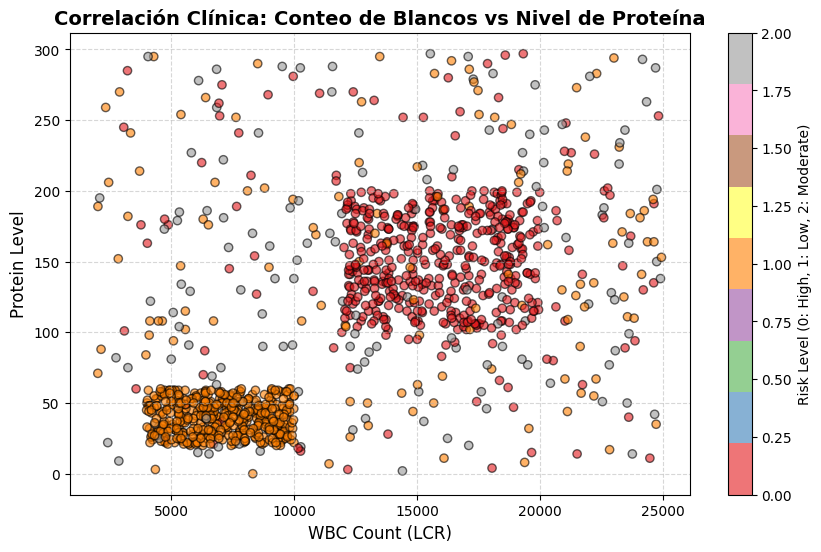

In [11]:
# ==============================================================================
# 5. VISUALIZACIÓN EXPLORATORIA: WBC vs PROTEÍNAS
# ==============================================================================
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['WBC_Count'], df['Protein_Level'],
            c=df['Risk_Level'], cmap='Set1', alpha=0.6, edgecolors='k')
plt.title('Correlación Clínica: Conteo de Blancos vs Nivel de Proteína', fontsize=14, fontweight='bold')
plt.xlabel('WBC Count (LCR)', fontsize=12)
plt.ylabel('Protein Level', fontsize=12)
plt.colorbar(scatter, label='Risk Level (0: High, 1: Low, 2: Moderate)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()